In [ ]:
import requests
import json
import pandas as pd
import numpy as np
from datetime import datetime
import time
import logging
from geopy.distance import geodesic
from geopy.geocoders import Nominatim

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [ ]:
# API endpoints
API_ENDPOINTS = {
    "temperature": "https://api-open.data.gov.sg/v2/real-time/api/air-temperature",
    "rainfall": "https://api-open.data.gov.sg/v2/real-time/api/rainfall",
    "humidity": "https://api-open.data.gov.sg/v2/real-time/api/relative-humidity",
    "wind_direction": "https://api-open.data.gov.sg/v2/real-time/api/wind-direction",
    "wind_speed": "https://api-open.data.gov.sg/v2/real-time/api/wind-speed",
}


In [ ]:
# Initialize geocoder
geolocator = Nominatim(user_agent="flood_prediction_sg")

# Cache for geocoded locations
geocode_cache = {}

In [ ]:
# Common Singapore locations for fallback
COMMON_LOCATIONS = {
    "orchard": (1.3036, 103.8318),
    "yishun": (1.4304, 103.8354),
    "tampines": (1.3546, 103.9450),
    "jurong": (1.3329, 103.7436),
    "bukit timah": (1.3294, 103.8021),
    "toa payoh": (1.3340, 103.8471),
    "changi": (1.3644, 103.9915),
    "bedok": (1.3236, 103.9273),
    "serangoon": (1.3554, 103.8679),
    "woodlands": (1.4382, 103.7891),
    "ang mo kio": (1.3691, 103.8454),
    "punggol": (1.3984, 103.9072),
    "bukit batok": (1.3590, 103.7637),
    "clementi": (1.3162, 103.7649),
    "hougang": (1.3719, 103.8930),
    "pasir ris": (1.3721, 103.9474),
    "novena": (1.3203, 103.8438),
    "paya lebar": (1.3178, 103.8918),
    "bishan": (1.3526, 103.8352),
    "buona vista": (1.3066, 103.7901),
    "boon lay": (1.3246, 103.7055),
    "choa chu kang": (1.3840, 103.7470),
    "marine parade": (1.3020, 103.9069),
    "kallang": (1.3100, 103.8716),
    "sengkang": (1.3868, 103.8914),
    "singapore": (1.3521, 103.8198)  # Center of Singapore as fallback
}

In [ ]:
def geocode_location(location_text):
    """
    Convert location text to coordinates with multiple fallback methods
    
    Parameters:
    - location_text: Text description of the location
    
    Returns:
    - Dictionary with latitude and longitude
    """
    # Check cache first
    if location_text in geocode_cache:
        return geocode_cache[location_text]
    
    # Try to match with common locations first (faster than geocoding)
    location_lower = location_text.lower()
    for name, coords in COMMON_LOCATIONS.items():
        if name in location_lower:
            result = {'latitude': coords[0], 'longitude': coords[1]}
            geocode_cache[location_text] = result
            logger.info(f"Matched '{location_text}' to common location '{name}'")
            return result
    
    # Try geocoding
    try:
        location = geolocator.geocode(f"{location_text}, Singapore", timeout=10)
        if location:
            result = {'latitude': location.latitude, 'longitude': location.longitude}
            geocode_cache[location_text] = result
            logger.info(f"Successfully geocoded '{location_text}'")
            return result
    except Exception as e:
        logger.warning(f"Error geocoding '{location_text}': {e}")
    
    # If geocoding fails, try to extract parts of the address
    try:
        # Try with main road or area name
        parts = location_text.split('(')[0].strip()  # Remove anything in parentheses
        if parts != location_text:
            location = geolocator.geocode(f"{parts}, Singapore", timeout=10)
            if location:
                result = {'latitude': location.latitude, 'longitude': location.longitude}
                geocode_cache[location_text] = result
                logger.info(f"Successfully geocoded simplified '{parts}'")
                return result
    except Exception:
        pass
    
    # Final fallback: use center of Singapore
    logger.warning(f"Could not geocode '{location_text}', using center of Singapore")
    result = {'latitude': 1.3521, 'longitude': 103.8198}
    geocode_cache[location_text] = result
    return result

In [ ]:
def fetch_api_data(api_type, date_time, max_retries=3):
    """
    Fetch data from the specified API
    
    Parameters:
    - api_type: Type of weather data (temperature, rainfall, etc.)
    - date_time: ISO format datetime string (YYYY-MM-DDTHH:MM:SS)
    
    Returns:
    - JSON response or None if error
    """
    url = API_ENDPOINTS[api_type]
    params = {
        "date": date_time
    }
    
    for attempt in range(max_retries):
        try:
            response = requests.get(url, params=params, timeout=10)
            if response.status_code == 200:
                return response.json()
            elif response.status_code == 404:
                logger.warning(f"No {api_type} data available for {date_time}")
                return None
            else:
                logger.warning(f"Error fetching {api_type} data: HTTP {response.status_code}")
                if attempt < max_retries - 1:
                    time.sleep(1)
        except Exception as e:
            logger.warning(f"Exception fetching {api_type} data: {e}")
            if attempt < max_retries - 1:
                time.sleep(1)
    
    return None

In [ ]:
def extract_stations_from_api(api_response):
    """
    Extract station information from API response
    
    Parameters:
    - api_response: JSON response from API
    
    Returns:
    - List of dictionaries with station info including coordinates
    """
    if not api_response or 'data' not in api_response or 'stations' not in api_response['data']:
        return []
    
    stations = []
    for station in api_response['data']['stations']:
        # Check if station has required data
        if 'id' in station and 'name' in station and 'location' in station:
            try:
                stations.append({
                    'id': station['id'],
                    'name': station['name'],
                    'latitude': station['location']['latitude'],
                    'longitude': station['location']['longitude']
                })
            except KeyError:
                continue
    
    return stations

In [ ]:
def find_nearest_station(stations, location_coords):
    """
    Find the nearest weather station to a specific location
    
    Parameters:
    - stations: List of station dictionaries with coordinates
    - location_coords: Dictionary with latitude and longitude
    
    Returns:
    - Dictionary with nearest station info or None if no stations
    """
    if not stations or not location_coords:
        return None
    
    nearest_station = None
    min_distance = float('inf')
    
    for station in stations:
        try:
            station_coords = (station['latitude'], station['longitude'])
            loc_coords = (location_coords['latitude'], location_coords['longitude'])
            
            # Calculate distance
            distance = geodesic(station_coords, loc_coords).kilometers
            
            if distance < min_distance:
                min_distance = distance
                nearest_station = {
                    'id': station['id'],
                    'name': station['name'],
                    'distance': distance
                }
        except (KeyError, ValueError):
            continue
    
    return nearest_station

In [ ]:
def get_station_value(api_response, station_id):
    """
    Get the value for a specific station from API response
    
    Parameters:
    - api_response: JSON response from API
    - station_id: ID of the station to find
    
    Returns:
    - Value from the station or None if not found
    """
    if not api_response or 'data' not in api_response or 'readings' not in api_response['data']:
        return None
    
    # Get the latest reading
    readings = api_response['data']['readings']
    if not readings:
        return None
    
    latest_reading = readings[-1]
    
    # Find the station in the data
    if 'data' in latest_reading:
        for item in latest_reading['data']:
            if item.get('stationId') == station_id and 'value' in item:
                return item['value']
    
    return None

In [ ]:
def create_flood_dataset_with_nearest_stations(flood_data_file, output_file="flood_data_nearest_stations_2.csv"):
    """
    Create dataset with nearest station data for each flood event
    
    Parameters:
    - flood_data_file: Path to JSON file with flood warning data
    - output_file: Path to output CSV file
    
    Returns:
    - DataFrame with flood events and nearest station data
    """
    # Load flood data
    try:
        with open(flood_data_file, 'r') as f:
            flood_data = json.load(f)
        logger.info(f"Loaded {len(flood_data)} flood events from {flood_data_file}")
    except Exception as e:
        logger.error(f"Error loading flood data: {e}")
        return None
    
    # Prepare list for data points
    data_points = []
    
    # Cache stations for each API
    api_stations_cache = {}
    
    # Process each flood event
    for i, flood in enumerate(flood_data):
        try:
            # Extract flood event details
            flood_datetime = flood['datetime']
            flood_location = flood['location']
            
            logger.info(f"Processing event {i+1}/{len(flood_data)}: {flood_location} at {flood_datetime}")
            
            # Geocode the flood location
            location_coords = geocode_location(flood_location)
            
            # Create data point with flood details
            data_point = {
                'datetime': flood_datetime,
                'location': flood_location,
                'latitude': location_coords['latitude'],
                'longitude': location_coords['longitude'],
                'flood': 1  # This is a flood event
            }
            
            # Process each API
            for api_type in API_ENDPOINTS.keys():
                # Get API data
                api_data = fetch_api_data(api_type, flood_datetime)
                
                if not api_data:
                    # No data available for this API
                    data_point[f"{api_type}_nearest_value"] = None
                    data_point[f"{api_type}_nearest_distance"] = None
                    data_point[f"{api_type}_nearest_station"] = None
                    continue
                
                # Extract stations if not already cached
                if api_type not in api_stations_cache:
                    stations = extract_stations_from_api(api_data)
                    api_stations_cache[api_type] = stations
                else:
                    stations = api_stations_cache[api_type]
                
                # Find nearest station
                nearest = find_nearest_station(stations, location_coords)

                if nearest:
                    # Get value from nearest station
                    value = get_station_value(api_data, nearest['id'])
                    
                    # Add to data point
                    data_point[f"{api_type}_nearest_value"] = value
                    data_point[f"{api_type}_nearest_distance"] = nearest['distance']
                    data_point[f"{api_type}_nearest_station"] = nearest['name']
                else:
                    # No nearest station found
                    data_point[f"{api_type}_nearest_value"] = None
                    data_point[f"{api_type}_nearest_distance"] = None
                    data_point[f"{api_type}_nearest_station"] = None
            
            # Add data point
            data_points.append(data_point)
            
            # Progress update
            if (i + 1) % 10 == 0:
                logger.info(f"Processed {i + 1}/{len(flood_data)} flood events")
            
            # Small delay to avoid API rate limits
            time.sleep(0.5)
        
        except Exception as e:
            logger.error(f"Error processing event {i+1}: {e}")
            continue  # Skip this event and continue
    
    # Convert to DataFrame
    if not data_points:
        logger.error("No data points collected")
        return None
    
    df = pd.DataFrame(data_points)
    
    # Clean up missing values
    df = df.fillna(0)
    
    # Save to CSV
    df.to_csv(output_file, index=False)
    logger.info(f"Dataset with nearest station data saved to {output_file}")
    
    return df

In [45]:
def create_ml_ready_dataset(flood_dataset, output_file="flood_ml_dataset.csv"):
    """
    Create a machine learning ready dataset from the flood dataset
    
    Parameters:
    - flood_dataset: DataFrame with flood events and nearest station data
    - output_file: Path to output CSV file
    
    Returns:
    - DataFrame with ML-ready features
    """
    if flood_dataset is None or len(flood_dataset) == 0:
        logger.error("No flood data available")
        return None
    
    # Create a copy of the dataset
    df = flood_dataset.copy()
    
    # Create balanced dataset (add non-flood examples)
    non_flood_rows = []
    for _, row in df.iterrows():
        # Create non-flood version with modified weather values
        non_flood = row.copy()
        non_flood['flood'] = 0
        
        # Reduce rainfall by 40-70%
        if 'rainfall_nearest_value' in non_flood and non_flood['rainfall_nearest_value'] > 0:
            non_flood['rainfall_nearest_value'] *= np.random.uniform(0.3, 0.6)
        
        # Reduce humidity slightly (5-15%)
        if 'humidity_nearest_value' in non_flood and non_flood['humidity_nearest_value'] > 0:
            non_flood['humidity_nearest_value'] *= np.random.uniform(0.85, 0.95)
        
        non_flood_rows.append(non_flood)
    
    # Add non-flood examples to dataset
    balanced_df = pd.concat([df, pd.DataFrame(non_flood_rows)])
    
    # Drop columns not needed for ML
    drop_columns = ['datetime', 'location']
    drop_columns.extend([col for col in balanced_df.columns if 'nearest_station' in col])
    
    ml_df = balanced_df.drop(columns=[col for col in drop_columns if col in balanced_df.columns])
    
    # Shuffle the dataset
    ml_df = ml_df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Save to CSV
    ml_df.to_csv(output_file, index=False)
    logger.info(f"ML-ready dataset saved to {output_file}")
    
    return ml_df

In [46]:
# Main execution
if __name__ == "__main__":
    flood_data_file = "flood_warnings_clean.json"  # Path to cleaned flood warning data
    
    # Create dataset with nearest station data
    flood_df = create_flood_dataset_with_nearest_stations(flood_data_file)
    
    if flood_df is not None:
        # Create ML-ready dataset
        ml_df = create_ml_ready_dataset(flood_df)
        
        print("\nDataset creation complete!")
        print(f"Flood dataset with nearest stations: {len(flood_df)} rows")
        if ml_df is not None:
            print(f"ML-ready dataset: {len(ml_df)} rows")
            print(f"Number of features: {len(ml_df.columns) - 1}")  # Excluding the target variable

2025-04-28 19:24:19,193 - INFO - Loaded 130 flood events from flood_warnings_clean.json
2025-04-28 19:24:19,194 - INFO - Processing event 1/130: Riverside Road (near Junction of Riverside Road and Admiralty Road) [Issued 14:40 hours]
PUB
@PUBsingapore
·
Apr 21
[Risk of Flash Floods]

Due to heavy rain, please avoid this location for the next 1 hour: Yishun Ave 7 (near intersection of Yishun St 22) at 2025-04-26T15:18:00


{'id': 'S106', 'deviceId': 'S106', 'name': 'Pulau Ubin', 'location': {'latitude': 1.4168, 'longitude': 103.9673}}
{'id': 'S117', 'deviceId': 'S117', 'name': 'Banyan Road', 'location': {'latitude': 1.256, 'longitude': 103.679}}
{'id': 'S107', 'deviceId': 'S107', 'name': 'East Coast Parkway', 'location': {'latitude': 1.3135, 'longitude': 103.9625}}
{'id': 'S104', 'deviceId': 'S104', 'name': 'Woodlands Avenue 9', 'location': {'latitude': 1.44387, 'longitude': 103.78538}}
{'id': 'S115', 'deviceId': 'S115', 'name': 'Tuas South Avenue 3', 'location': {'latitude': 1.29377, 'longitude': 103.61843}}
{'id': 'S102', 'deviceId': 'S102', 'name': 'Semakau Landfill', 'location': {'latitude': 1.189, 'longitude': 103.768}}
{'id': 'S60', 'deviceId': 'S60', 'name': 'Sentosa', 'location': {'latitude': 1.25, 'longitude': 103.8279}}
{'id': 'S50', 'deviceId': 'S50', 'name': 'Clementi Road', 'location': {'latitude': 1.3337, 'longitude': 103.7768}}
{'id': 'S44', 'deviceId': 'S44', 'name': 'Nanyang Avenue', 'lo

2025-04-28 19:24:23,885 - INFO - Processing event 2/130: Jln Pokok Serunai at 2025-04-20T17:19:00


[{'id': 'S106', 'name': 'Pulau Ubin', 'latitude': 1.4168, 'longitude': 103.9673}, {'id': 'S117', 'name': 'Banyan Road', 'latitude': 1.256, 'longitude': 103.679}, {'id': 'S107', 'name': 'East Coast Parkway', 'latitude': 1.3135, 'longitude': 103.9625}, {'id': 'S104', 'name': 'Woodlands Avenue 9', 'latitude': 1.44387, 'longitude': 103.78538}, {'id': 'S115', 'name': 'Tuas South Avenue 3', 'latitude': 1.29377, 'longitude': 103.61843}, {'id': 'S102', 'name': 'Semakau Landfill', 'latitude': 1.189, 'longitude': 103.768}, {'id': 'S60', 'name': 'Sentosa', 'latitude': 1.25, 'longitude': 103.8279}, {'id': 'S50', 'name': 'Clementi Road', 'latitude': 1.3337, 'longitude': 103.7768}, {'id': 'S44', 'name': 'Nanyang Avenue', 'latitude': 1.34583, 'longitude': 103.68166}, {'id': 'S43', 'name': 'Kim Chuan Road', 'latitude': 1.3399, 'longitude': 103.8878}, {'id': 'S24', 'name': 'Upper Changi Road North', 'latitude': 1.3678, 'longitude': 103.9826}, {'id': 'S111', 'name': 'Scotts Road', 'latitude': 1.31055, '

2025-04-28 19:24:28,223 - INFO - Processing event 3/130: Alexandra Rd (opp Alexis Condo) at 2025-04-20T17:19:00


...

[{'id': 'S106', 'name': 'Pulau Ubin', 'latitude': 1.4168, 'longitude': 103.9673}, {'id': 'S117', 'name': 'Banyan Road', 'latitude': 1.256, 'longitude': 103.679}, {'id': 'S107', 'name': 'East Coast Parkway', 'latitude': 1.3135, 'longitude': 103.9625}, {'id': 'S104', 'name': 'Woodlands Avenue 9', 'latitude': 1.44387, 'longitude': 103.78538}, {'id': 'S115', 'name': 'Tuas South Avenue 3', 'latitude': 1.29377, 'longitude': 103.61843}, {'id': 'S102', 'name': 'Semakau Landfill', 'latitude': 1.189, 'longitude': 103.768}, {'id': 'S60', 'name': 'Sentosa', 'latitude': 1.25, 'longitude': 103.8279}, {'id': 'S50', 'name': 'Clementi Road', 'latitude': 1.3337, 'longitude': 103.7768}, {'id': 'S44', 'name': 'Nanyang Avenue', 'latitude': 1.34583, 'longitude': 103.68166}, {'id': 'S43', 'name': 'Kim Chuan Road', 'latitude': 1.3399, 'longitude': 103.8878}, {'id': 'S24', 'name': 'Upper Changi Road North', 'latitude': 1.3678, 'longitude': 103.9826}, {'id': 'S111', 'name': 'Scotts Road', 'latitude': 1.31055, '

2025-04-28 19:37:04,579 - INFO - Processed 130/130 flood events


[{'id': 'S108', 'name': 'Marina Gardens Drive', 'latitude': 1.2799, 'longitude': 103.8703}, {'id': 'S44', 'name': 'Nanyang Avenue', 'latitude': 1.34583, 'longitude': 103.68166}, {'id': 'S106', 'name': 'Pulau Ubin', 'latitude': 1.4168, 'longitude': 103.9673}, {'id': 'S117', 'name': 'Banyan Road', 'latitude': 1.256, 'longitude': 103.679}, {'id': 'S43', 'name': 'Kim Chuan Road', 'latitude': 1.3399, 'longitude': 103.8878}, {'id': 'S107', 'name': 'East Coast Parkway', 'latitude': 1.3135, 'longitude': 103.9625}, {'id': 'S115', 'name': 'Tuas South Avenue 3', 'latitude': 1.29377, 'longitude': 103.61843}, {'id': 'S102', 'name': 'Semakau Landfill', 'latitude': 1.189, 'longitude': 103.768}, {'id': 'S111', 'name': 'Scotts Road', 'latitude': 1.31055, 'longitude': 103.8365}, {'id': 'S60', 'name': 'Sentosa', 'latitude': 1.25, 'longitude': 103.8279}, {'id': 'S50', 'name': 'Clementi Road', 'latitude': 1.3337, 'longitude': 103.7768}]
Distance to Marina Gardens Drive: 6.68 km
Distance to Nanyang Avenue: 

2025-04-28 19:37:05,087 - INFO - Dataset with nearest station data saved to flood_data_nearest_stations_2.csv
2025-04-28 19:37:05,109 - INFO - ML-ready dataset saved to flood_ml_dataset.csv



Dataset creation complete!
Flood dataset with nearest stations: 130 rows
ML-ready dataset: 260 rows
Number of features: 12


ValueError: too many values to unpack (expected 2)

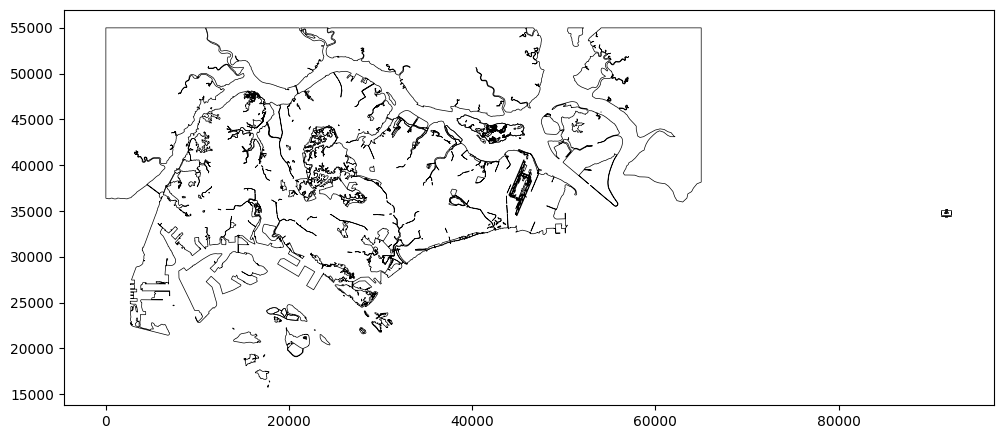

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap
import scipy.ndimage as ndimage
from shapely.geometry import box, Polygon
import contextily as ctx
import pandas as pd
import json
from matplotlib.path import Path
from matplotlib.patches import PathPatch


singapore = gpd.read_file('SingaporeMap_Polygon.shp')  # or GeoJSON file

# 2. Get geographic bounds
x_min, y_min, x_max, y_max = singapore.total_bounds
grid_size = 100  # Roughly 1km in degrees for this demo

# 3. Create grid coordinates
x_coords = np.arange(x_min, x_max, grid_size)
y_coords = np.arange(y_min, y_max, grid_size)

# 4. Create mock risk data
# Function to generate mock risk data with realistic patterns
def generate_mock_risk_data(x_coords, y_coords):
    nx = len(x_coords)
    ny = len(y_coords)
    risk_values = np.zeros((ny, nx))
    
    # Create some "hotspot" areas
    num_hotspots = 5
    for _ in range(num_hotspots):
        center_x = np.random.randint(0, nx)
        center_y = np.random.randint(0, ny)
        radius = np.random.randint(2, 5)
        intensity = np.random.uniform(0.6, 1.0)
        
        for y in range(ny):
            for x in range(nx):
                # Distance from hotspot center
                dist = np.sqrt((x - center_x)**2 + (y - center_y)**2)
                if dist <= radius:
                    # Decay from center
                    contribution = intensity * (1 - dist/radius)
                    risk_values[y, x] = max(risk_values[y, x], contribution)
    
    # Add some noise for realism
    risk_values += np.random.normal(0, 0.05, (ny, nx))
    risk_values = np.clip(risk_values, 0, 1)
    
    return risk_values

# Generate mock risk data
risk_values = generate_mock_risk_data(x_coords, y_coords)

# 5. Apply smoothing
sigma = 1.5  # Adjust for desired smoothness
smoothed_risk = ndimage.gaussian_filter(risk_values, sigma=sigma)

# 6. Create custom colormap (green to red with transparency)
colors = [(0, 1, 0, 0.5),    # Green with 50% transparency
          (1, 1, 0, 0.6),    # Yellow with 60% transparency 
          (1, 0, 0, 0.7)]    # Red with 70% transparency
cmap = LinearSegmentedColormap.from_list('risk_cmap', colors, N=256)

# 7. Create the plot
fig, ax = plt.subplots(figsize=(12, 12))
singapore.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)  # Plot SG outline

# 8. Create a mask from Singapore's shape
mask = np.ones(smoothed_risk.shape, dtype=bool)

# For each geometry in the GeoDataFrame
for geom in singapore.geometry:
    # Convert geometry to pixels in the image
    pixel_coords = []
    for x, y in geom.exterior.coords:
        pixel_x = np.argmin(np.abs(x_coords - x))
        pixel_y = np.argmin(np.abs(y_coords - y))
        pixel_coords.append((pixel_x, len(y_coords) - pixel_y - 1))  # Adjust for image coords
    
    # Create path and mask
    path = Path(pixel_coords)
    for y in range(mask.shape[0]):
        for x in range(mask.shape[1]):
            if path.contains_point((x, y)):
                mask[y, x] = False

# 9. Apply mask to smoothed data
masked_data = np.copy(smoothed_risk)
masked_data[mask] = np.nan  # NaN values will be transparent

# 10. Plot with mask applied
im = ax.imshow(masked_data, extent=[x_min, x_max, y_min, y_max], 
              cmap=cmap, interpolation='bilinear')

# 11. Add basemap (using contextily)
try:
    ctx.add_basemap(ax, crs=singapore.crs)  # Add OpenStreetMap basemap
except Exception as e:
    print(f"Could not add basemap: {e}")
    print("Continuing without basemap")

# 12. Add colorbar
plt.colorbar(im, ax=ax, label='Risk Level', orientation='vertical', shrink=0.7)

# 13. Add title
plt.title('Singapore Risk Map (Mock Data)', fontsize=16)

# 14. Save with transparency
plt.axis('off')
plt.savefig('singapore_risk_map.png', bbox_inches='tight', pad_inches=0, 
           transparent=True, dpi=300)

# 15. Save bounds for web integration
bounds = [x_min, y_min, x_max, y_max]
with open('risk_map_bounds.json', 'w') as f:
    json.dump(bounds, f)

print("Risk map generated with mock data!")
print(f"Map saved as 'singapore_risk_map.png'")
print(f"Bounds saved as 'risk_map_bounds.json'")

# 16. Create a figure showing the raw risk data for reference
plt.figure(figsize=(10, 10))
plt.imshow(risk_values, cmap='RdYlGn_r', origin='lower')
plt.colorbar(label='Raw Risk Values')
plt.title('Raw Risk Data (Before Smoothing)')
plt.savefig('raw_risk_data.png')
print("Raw risk data saved as 'raw_risk_data.png'")

In [9]:
import geopandas as gpd
from shapely.geometry import box
import numpy as np

# Load Singapore boundary
singapore = gpd.read_file('SingaporePoliceForceNPCBoundary.geojson')

# Create grid (ensure CRS matches)
minx, miny, maxx, maxy = singapore.total_bounds
cell_size = 500/110000  # in meters (make sure your CRS uses meters)

# Create grid cells
grid_cells = []
for x0 in np.arange(minx, maxx, cell_size):
    for y0 in np.arange(miny, maxy, cell_size):
        # Create box
        cell = box(x0, y0, x0+cell_size, y0+cell_size)
        grid_cells.append(cell)

# Convert to GeoDataFrame
grid = gpd.GeoDataFrame(geometry=grid_cells, crs=singapore.crs)

# Only keep cells that intersect with land
grid_on_land = grid[grid.intersects(singapore.unary_union)]

# Assign grid IDs
grid_on_land['grid_id'] = [f"G{i}" for i in range(len(grid_on_land))]

# Add your risk scores (from your ML model)
# This is where you'd add your risk data for each cell
# For this example, I'm generating random values
grid_on_land['flood_risk'] = np.random.random(len(grid_on_land))
grid_on_land['fire_risk'] = np.random.random(len(grid_on_land))
grid_on_land['crime_risk'] = np.random.random(len(grid_on_land))

# Save to GeoJSON
grid_on_land.to_file('singapore-grid-cells.geojson', driver='GeoJSON')

C:\Users\William\AppData\Local\Temp\ipykernel_40228\2125338267.py:24: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  grid_on_land = grid[grid.intersects(singapore.unary_union)]
c:\Users\William\Documents\huawei\env\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\William\Documents\huawei\env\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-

In [ ]:
import json

def extract_main_island_aoi(feature_collection):
    for feature in feature_collection["features"]:
        if feature["properties"].get("Name") == "kml_533":
            coords = feature["geometry"]["coordinates"][0]  # Only outer boundary
            return [{"lat": lat, "lon": lon} for lon, lat, *_ in coords]
    raise ValueError("Feature with Name 'kml_533' not found")

# Load your FeatureCollection JSON file
with open("NationalMapPolygonKML.geojson", "r", encoding="utf-8") as f:
    data = json.load(f)

aoi = extract_main_island_aoi(data)

# Output result
print(json.dumps({"aoi": aoi}, indent=2))


UnicodeDecodeError: 'charmap' codec can't decode byte 0x9d in position 277151: character maps to <undefined>